# Attention (PyTorch)

Instead of summarizing a whole sequence into a single final hidden state (as
[`LSTM`](../07_LSTM)/[`GRU`](../08_GRU) do), an **attention** mechanism lets the model
look back at *every* hidden state and learn how much weight to give each one when
making its decision. Those weights ("attention scores") are also interpretable — we
can see exactly which words the model focused on.

Same task and pipeline as `06_RNN`/`07_LSTM`/`08_GRU` — newsgroup posts, **hockey vs.
space** — but now an LSTM returns hidden states for *every* token, and a small
additive-attention layer learns to weight them before classification.

In [1]:
import re
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.datasets import fetch_20newsgroups

torch.manual_seed(0)

categories = ["rec.sport.hockey", "sci.space"]
train = fetch_20newsgroups(subset="train", categories=categories,
                            remove=("headers", "footers", "quotes"))
test = fetch_20newsgroups(subset="test", categories=categories,
                          remove=("headers", "footers", "quotes"))
len(train.data), len(test.data), train.target_names

(1193, 793, ['rec.sport.hockey', 'sci.space'])

In [2]:
MAX_VOCAB = 5000
MAX_LEN = 150


def tokenize(text):
    return re.findall(r"[a-z]+", text.lower())


train_tokens = [tokenize(doc) for doc in train.data]
test_tokens = [tokenize(doc) for doc in test.data]

counter = Counter(tok for toks in train_tokens for tok in toks)
vocab = {"<pad>": 0, "<unk>": 1}
for word, _ in counter.most_common(MAX_VOCAB - len(vocab)):
    vocab[word] = len(vocab)
inv_vocab = {i: w for w, i in vocab.items()}


def encode(tokens):
    ids = [vocab.get(t, vocab["<unk>"]) for t in tokens][:MAX_LEN]
    ids += [vocab["<pad>"]] * (MAX_LEN - len(ids))
    return ids


X_train = torch.tensor([encode(t) for t in train_tokens], dtype=torch.long)
X_test = torch.tensor([encode(t) for t in test_tokens], dtype=torch.long)
y_train = torch.tensor(train.target, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(test.target, dtype=torch.float32).view(-1, 1)

vocab_size = len(vocab)
X_train.shape, vocab_size

(torch.Size([1193, 150]), 5000)

In [3]:
class AdditiveAttention(nn.Module):
    """Learns a weight per timestep: score_t = v . tanh(W h_t), then softmax."""

    def __init__(self, hidden_dim):
        super().__init__()
        self.W = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, h, mask):
        scores = self.v(torch.tanh(self.W(h))).squeeze(-1)   # (batch, seq_len)
        # Use a large finite negative instead of -inf: a handful of newsgroup posts
        # tokenize to zero real words (all-padding rows), and softmax(-inf, ..., -inf)
        # is 0/0 = NaN, whereas softmax(-1e9, ..., -1e9) is a well-defined uniform dist.
        scores = scores.masked_fill(~mask, -1e9)               # ignore padding
        alpha = torch.softmax(scores, dim=1)                  # attention weights
        context = torch.bmm(alpha.unsqueeze(1), h).squeeze(1)  # weighted sum of h
        return context, alpha


class AttentionClassifier(nn.Module):
    def __init__(self, vocab_size, emb_dim=32, hidden_dim=32):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(emb_dim, hidden_dim, batch_first=True)
        self.attention = AdditiveAttention(hidden_dim)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        mask = x != 0
        embedded = self.embedding(x)
        h, _ = self.lstm(embedded)            # (batch, seq_len, hidden_dim) - every step
        context, alpha = self.attention(h, mask)
        return self.fc(context), alpha


model = AttentionClassifier(vocab_size)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [4]:
losses = []
for epoch in range(15):
    optimizer.zero_grad()
    logits, _ = model(X_train)
    loss = criterion(logits, y_train)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    print(f"epoch {epoch+1:2d}  loss {loss.item():.4f}")

epoch  1  loss 0.6953
epoch  2  loss 0.6880


epoch  3  loss 0.6815
epoch  4  loss 0.6755
epoch  5  loss 0.6656


epoch  6  loss 0.6478
epoch  7  loss 0.6208
epoch  8  loss 0.5812


epoch  9  loss 0.5419
epoch 10  loss 0.5091
epoch 11  loss 0.4794


epoch 12  loss 0.4482
epoch 13  loss 0.4053
epoch 14  loss 0.3683


epoch 15  loss 0.3368


Test accuracy: 0.831


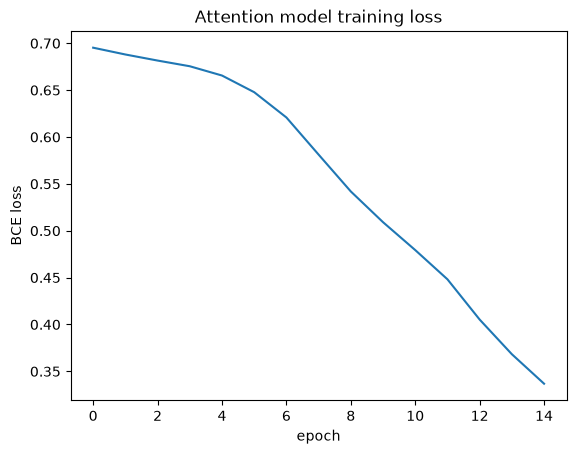

In [5]:
with torch.no_grad():
    test_logits, test_alpha = model(X_test)
    preds = torch.sigmoid(test_logits) >= 0.5
    accuracy = (preds.float() == y_test).float().mean().item()
print(f"Test accuracy: {accuracy:.3f}")

plt.plot(losses)
plt.xlabel("epoch")
plt.ylabel("BCE loss")
plt.title("Attention model training loss")
plt.show()

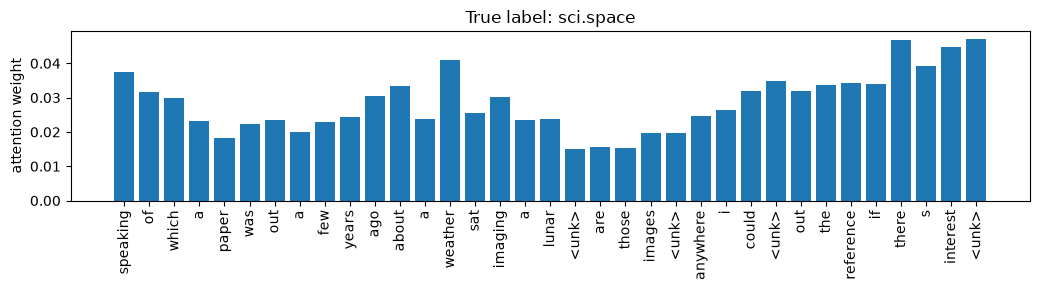

In [6]:
# Visualize attention weights for one test example
i = 0
length = int((X_test[i] != 0).sum())
tokens = [inv_vocab[t.item()] for t in X_test[i, :length]]
weights = test_alpha[i, :length].numpy()

plt.figure(figsize=(max(8, length * 0.3), 3))
plt.bar(range(length), weights)
plt.xticks(range(length), tokens, rotation=90)
plt.ylabel("attention weight")
plt.title(f"True label: {test.target_names[int(y_test[i].item())]}")
plt.tight_layout()
plt.show()